<a href="https://colab.research.google.com/github/muammarzainza2000/data-science-2026/blob/main/Pertemuan5_Muammar_Zain_Z_A_240401010304.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns

(891, 15) survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object
       survived  pclass     age   sibsp   parch    fare
count    891.00  891.00  714.00  891.00  891.00  891.00
mean       0.38    2.31   29.70    0.52    0.38   32.20
std        0.49    0.84   14.53    1.10    0.81   49.69
min        0.00    1.00    0.42    0.00    0.00    0.00
25%        0.00    2.00   20.12    0.00    0.00    7.91
50%        0.00    3.00   28.00    0.00    0.00   14.45
75%        1.00    3.00   38.00    1.00    0.00   31.00
max        1.00    3.00   80.00    8.00    6.00  512.33


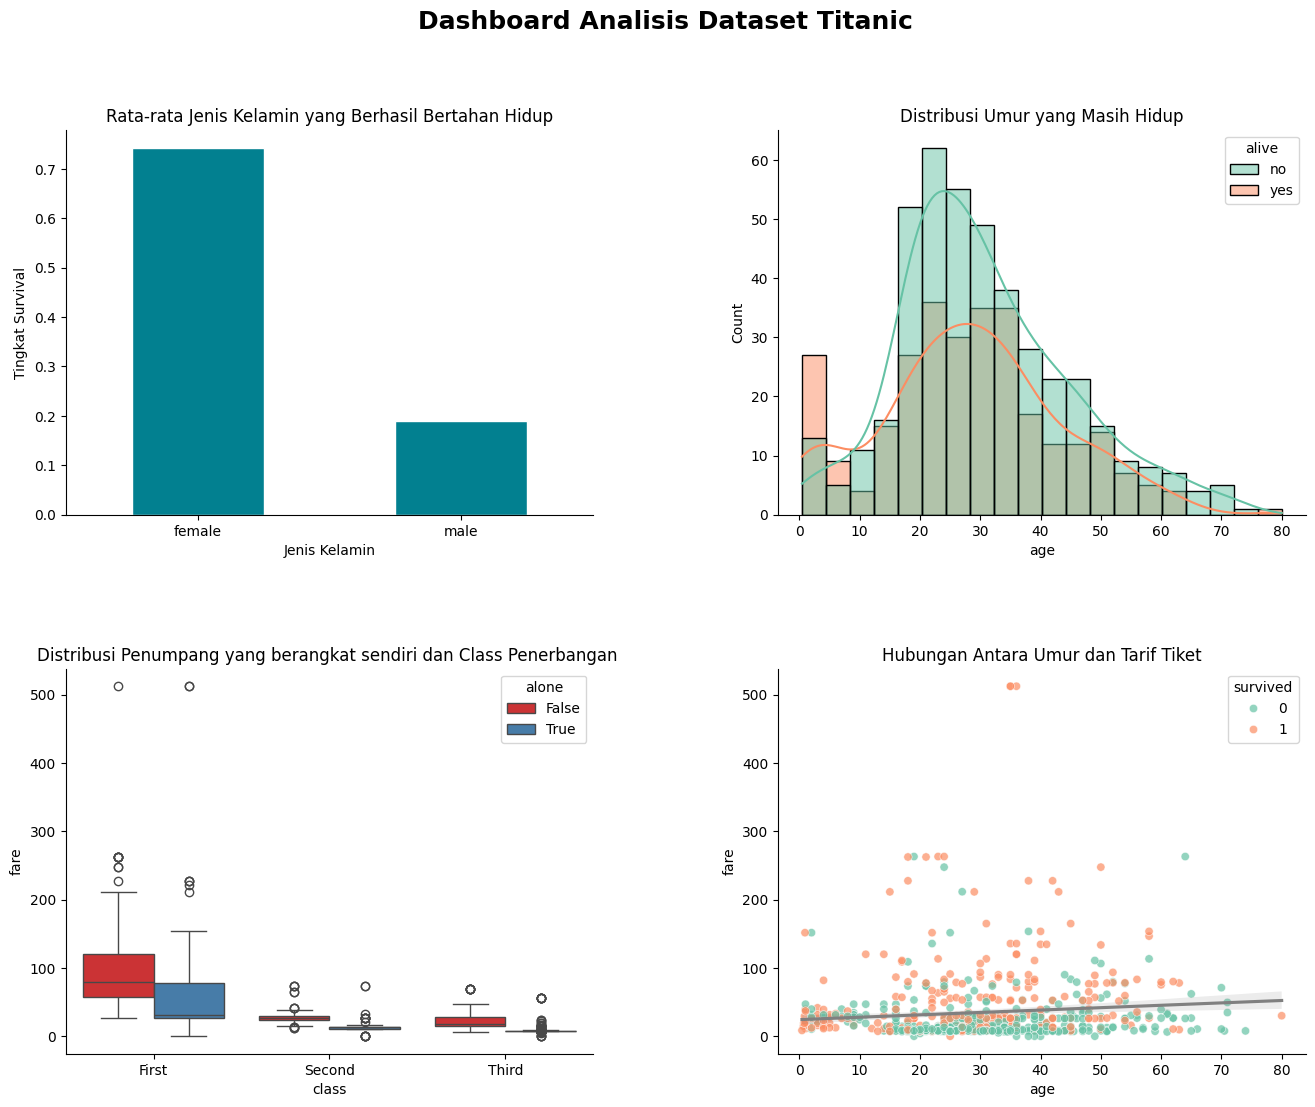

Dashboard tersimpan sebagai dashboard_tips.png


In [ ]:
# ── 1. LOAD & INSPECT DATASET ──────────────────────────────────────────
df = sns.load_dataset('titanic')
print(df.shape, df.dtypes)
print(df.describe().round(2))

# ── 2. SETUP FIGURE LAYOUT ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Titanic',
 fontsize=18, fontweight='bold', y=0.98)

# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig,
 hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

# ── 3. GRAFIK 1: Bar Chart ─────────────────────────────────────────────
avg_by_day = df.groupby('sex')['survived'].mean()
avg_by_day.plot(kind='bar', ax=ax1, color='#028090',
 edgecolor='white')
ax1.set_title('Rata-rata Jenis Kelamin yang Berhasil Bertahan Hidup')
ax1.set_xlabel('Jenis Kelamin'); ax1.set_ylabel('Tingkat Survival')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

# ── 4. GRAFIK 2: Histogram + KDE ───────────────────────────────────────
sns.histplot(data=df, x='age', hue='alive',
 kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Umur yang Masih Hidup')
ax2.spines[['top','right']].set_visible(False)

# ── 5. GRAFIK 3: Boxplot ───────────────────────────────────────────────
sns.boxplot(data=df, x='class', y='fare',
 hue='alone', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Penumpang yang berangkat sendiri dan Class Penerbangan ')
ax3.spines[['top','right']].set_visible(False)

# ── 6. GRAFIK 4: Scatter Plot ──────────────────────────────────────────
sns.scatterplot(data=df, x='age', y='fare',
 hue='survived', sizes=(30,180),
palette='Set2', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='age', y='fare',
 scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Antara Umur dan Tarif Tiket')
ax4.spines[['top','right']].set_visible(False)

# ── 7. EKSPOR ──────────────────────────────────────────────────────────
plt.savefig('dashboard_tips.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_tips.png')

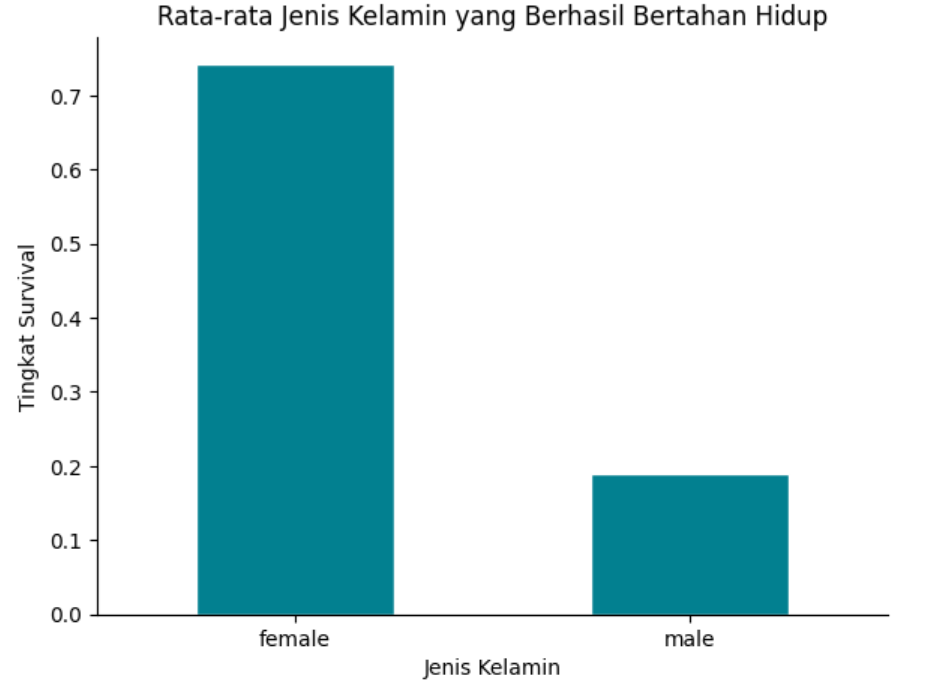

**What? (Apa yang terlihat)**: Grafik ini menunjukkan perbedaan  tingkat keselamatan berdasarkan gender. Penumpang perempuan (female) memiliki tingkat keselamatan sangat tinggi di angka sekitar 0.74 (atau 74%). Sebaliknya, penumpang laki-laki (male) memiliki tingkat keselamatan yang jauh lebih rendah, yaitu di bawah 0.2, tepatnya sekitar 0.19 (atau 19%).

**So what? (Mengapa penting)**: Angka ini mengonfirmasi secara kuat bahwa protokol evakuasi "Women and children first" (Wanita dan anak-anak didahulukan) benar-benar diterapkan secara ketat saat tragedi Titanic. Gender adalah salah satu faktor prediktor paling dominan dalam menentukan siapa yang hidup dan mati di kapal tersebut.

**Now what? (Tindak lanjut/Eksplorasi)**: Apakah privilese gender ini berlaku merata di semua kelas sosial? Mari kita pecah data keselamatan perempuan ini berdasarkan kelas tiketnya (First, Second, Third) untuk melihat apakah perempuan di Kelas Tiga memiliki peluang selamat yang sama tingginya dengan perempuan di Kelas Satu.

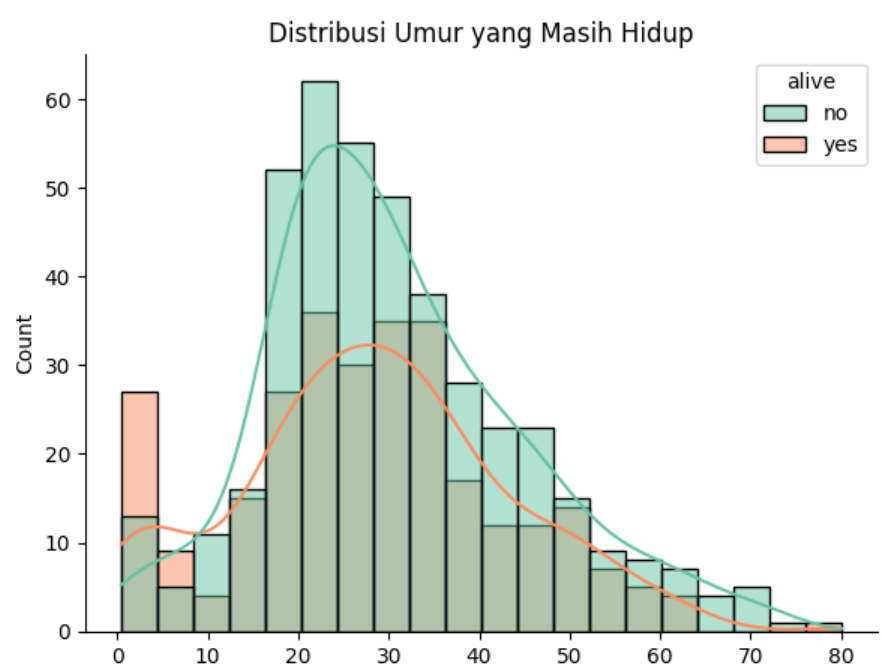

**What? (Apa yang terlihat)**: Histogram ini membandingkan sebaran umur penumpang yang selamat (oranye/yes) dan tidak (hijau/no). Terlihat lonjakan tajam pada kotak hijau (tidak selamat) di rentang usia produktif 20-30 tahun, di mana angka kematian mencapai puncaknya (lebih dari 60 orang di satu rentang usia). Menariknya, pada kelompok balita (rentang 0-5 tahun), grafik oranye melampaui hijau; sekitar 25 anak selamat dibandingkan belasan yang tidak.

**So what? (Mengapa penting)**: Ini mempertegas bagian "anak-anak" dari protokol keselamatan evakuasi. Balita memiliki prioritas penyelamatan yang sangat baik. Di sisi lain, tingginya angka kematian di usia 20-30 tahun kemungkinan besar merepresentasikan kelompok pria lajang kelas tiga dan kru kapal pria yang mengorbankan diri atau tertahan di dek bawah.

**Now what? (Tindak lanjut/Eksplorasi)**: Buat kategori usia yang lebih terstruktur (misal: Infant, Child, Teen, Adult, Senior) dan hitung persentase keselamatan absolut per grup. Apakah kelompok lansia (di atas 60 tahun) memiliki peluang yang sama dengan kelompok dewasa muda?

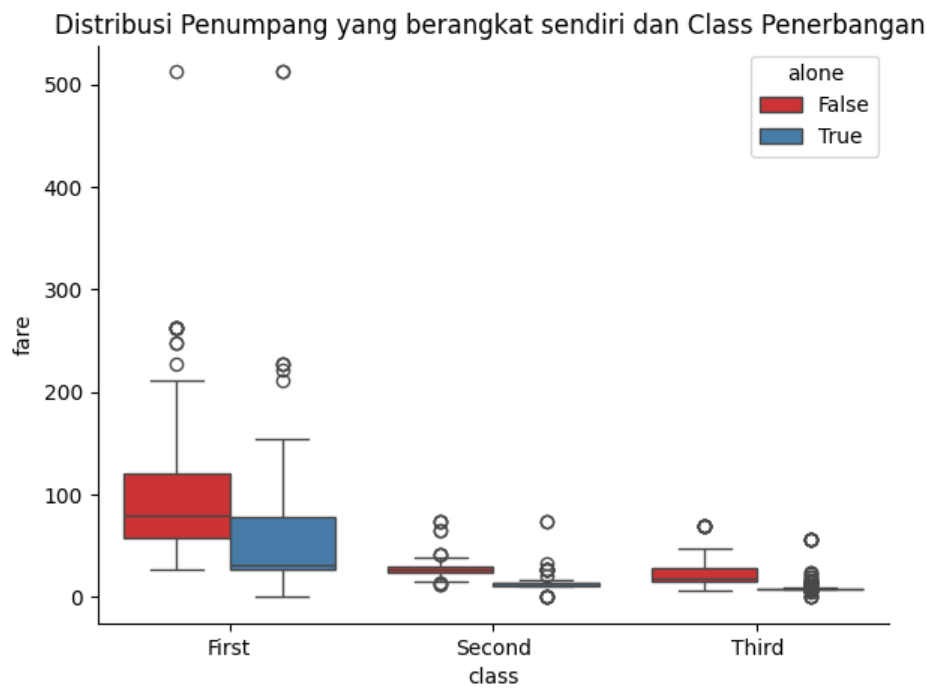

**What? (Apa yang terlihat)**: Boxplot menunjukkan sebaran harga tiket (fare) di setiap kelas. Di Kelas Pertama (First), median harga tiket bagi yang tidak pergi sendiri/membawa keluarga (merah, alone=False) berada di sekitar angka 80, jauh lebih tinggi dari median yang bepergian sendiri (biru) di angka 50. Terlihat juga beberapa pencilan (outlier) ekstrem di Kelas Pertama di mana harga tiket mencapai lebih dari 500. Di Kelas Dua dan Tiga, harga tiket sangat terkompresi dengan median di bawah 30.

**So what? (Mengapa penting)**: Perbedaan harga tiket di Kelas Satu membuktikan bahwa penumpang yang membawa keluarga besar membayar tiket kolektif atau menyewa kabin suite yang jauh lebih mahal. Adanya gap harga yang masif antara Kelas Satu dan Kelas Tiga (>500 vs <30) menunjukkan disparitas sosial-ekonomi penumpang yang sangat ekstrem.

**Now what? (Tindak lanjut/Eksplorasi)**: Siapakah penumpang-penumpang (outlier) yang membayar tiket seharga >500 tersebut? Kita perlu mengekstrak nama mereka dan melihat apakah harga super premium yang mereka bayar menjamin akses langsung ke sekoci penyelamat 100%.

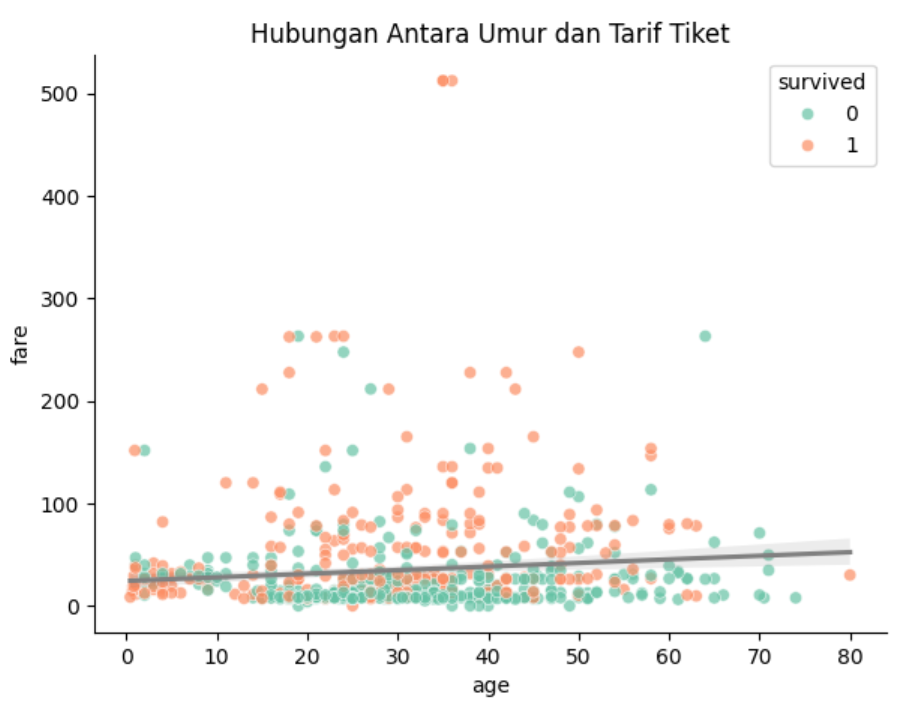

**What? (Apa yang terlihat)**: Grafik sebar ini memetakan umur dan tarif tiket, diwarnai dengan status selamat (1 = oranye, 0 = hijau). Kepadatan data tertinggi ada di bagian bawah (tarif < 50) lintas semua rentang usia, yang merupakan campuran antara titik hijau dan oranye. Namun, jika kita melihat ke atas (tarif > 100), titik-titik oranye (selamat) terlihat jauh lebih mendominasi daripada titik hijau. Penumpang dengan tarif ekstrem (> 500) di usia sekitar 35-40 tahun juga berstatus oranye.

**So what? (Mengapa penting)**: Visualisasi ini dengan jelas menggambarkan pepatah kelam Titanic: "Kekayaan tidak bisa membeli nyawa, tetapi bisa membeli sekoci". Semakin mahal tiket yang dibayarkan, persentase titik keselamatan (oranye) semakin padat. Garis regresi (garis lurus di bawah) juga menunjukkan korelasi positif kecil bahwa penumpang yang lebih tua cenderung memiliki uang lebih untuk membeli tiket yang sedikit lebih mahal.

**Now what? (Tindak lanjut/Eksplorasi)**: Karena titik-titik saling menumpuk (overplotting) di area tarif rendah, agak sulit membaca rasio keselamatannya secara presisi. Langkah berikutnya adalah melakukan binning (pengelompokan) pada kolom fare (misal: 0-50, 50-100, >100) dan membuat rasio keselamatan untuk melihat dampak ekonomi secara lebih kuantitatif dan jelas.